# **SC1003 Introduction to Computational Thinking & Programming**
## **A Simulated-Annealing-Based Heuristic Team Allocator**
### **Group Members**
1. Cleavon Yeo Kaiyi
2. Darren Ang Hao En
3. Denzell Teo Kai Feng
4. De Vera Hans Gabriel Dacon
5. Dickson Tan Choon Yin

## Background

The **Introduction to Data Science** course offered by Nanyang Technological University (NTU) is quite popular, admitting a cohort of approximately 6000 students in different courses and with varying backgrounds. Students are assigned into one of 120 tutorial group, each with around 50 students.

The sheer number of students enrolled in this course has made any form of manual grouping for group projects tedious, if not impossible. Given the concerns of the course organizers, we have developed a solution that **assigns students into groups**.

Specifically, our algorithm attempts to form groups that satisfy the following properties:
1. The groups are **equitably distributed by gender** within each tutorial group.
2. The groups are **balanced** in terms of **average CGPA** --- no group has a significantly better or worse average CGPA compared to any other group.
3. The groups are composed of **students from a variety of schools** --- no one school is dominant or underrepresented in the groups, ensuring a healthy distribution of students from varied backgrounds and thereby enabling interdisciplinary discourse.

These groups must be subject to the following constraints:
1. The algorithm must **assign all students to a unique group**. Formally, each student should belong to *exactly one group*.
2. Each group must be of **roughly equal size**. Formally, the maximum number of students in a group minus the minimum number of students in a group must be at most 1.
3. Each group must be composed of students from a **single tutorial group**.

We have opted to develop a **heuristic optimizer that uses Simulated Annealing** in Python to achieve this task. First, we formulated the problem of group assignment as an instance of a **discrete optimization problem** with the goal of **minimizing a set objective**. We will delve into the specifics of this reduction and the chosen objective later on.

The program expects, as input, a `records.csv` file containing the data entries of all students in the course. The algorithm then outputs a CSV file with the same data entries in the exact same order as `records.csv`, but augments each entry with the assigned group code.

Using the heuristic optimizer with a pre-sorted input state, we achieve **near-optimal** grouping results with an algorithm that easily scales to larger datasets.

## Computational Thinking

Pursuant to the learning objectives of this course, we have applied **Computational Thinking** (CT) in our decision-making and algorithms design, as follows:

### Decomposition

The process of reducing the algorithm to a discrete optimization problem required multiple steps. We split these steps into smaller, modularized functions to facilitate development and debugging.

### Pattern Recognition

We used prior experience with past problems to attack the problem of group assignment. Specifically, one of us drew inspiration from a past solution to the 2017 International Olympiad in Informatics (IOI) problem titled "[Nowruz](https://oj.uz/problem/view/IOI17_nowruz)". Both that problem and group assignment share a similar property: They can be formulated as **discrete optimization problems**.

An **optimization problem** is a problem of the following type:

> Given the set of all possible states $X$ and an energy function $E: X \to \mathbb{R}$ that assigns each state in $X$ an "energy", find the state $x \in X$ that minimizes $E(x)$. In mathematical notation, compute $\text{argmin}_{x \in X} E(x)$.

In our case, the resulting optimization problem is **discrete** because we are finding a grouping that minimizes a certain energy function (to be defined later). The set of groupings is finite. In contrast, an example of a **continuous** optimization problem would be to find the input that minimizes a real-valued function.

Furthermore, we encoded all of the data as vectors so that we can apply the same grouping logic for all variables. Thus, instead of separately considering school, gender, and CGPA, we aggregate all of this data into a vector and thus deal with them in unison.  

### Abstraction

The other benefit of modularizing the code is that we were able to develop from a **top-down perspective**: Instead of considering every single line of code, we could rely on predefined functions. This enabled code reuse and also made the code more declarative and readable --- the function names were descriptive enough to allow us to understand what it does.

### Algorithmic Thinking

Once we have reduced the problem to an instance of discrete optimization, we used **simulated annealing** to solve the resulting optimization problem.

Of course, this meant that we had to implement simulated annealing. To do this, we had to review how we implemented simulated annealing before and listed out the steps of the algorithm.

Then, we translated that rough step-by-step outline into actual python code that captures the behavior of the algorithm.

This process was then repeated for all of the other helper functions we wrote --- `run_optimizer`, `mean_stddev`, etc.

## Planning & Design

### 1. Problem Decomposition: General Pseudocode

The algorithm developed tackles both the basic and the enhanced versions of the problem. Thus, we have unified both parts of the report into one part.

We have subdivided the problem into **four main parts:**

1. **Reading Input:** We wrote the code to read the `records.csv` file. To do this, we had to familiarize ourselves with the comma-separated format of `.csv` files. We further subdivided this part as follows:
   1. Ask the user to input a `group_size` from (4-10), performing input validation as necessary.
   2. Use Python's **open** function to open the `.csv` file in **read** mode and store it as a string.
   3. Use the **string.split** method to split along the commas, thereby isolating each data entry.
   4. Convert each entry into a string or integer, as necessary.
2. **Converting Each Datapoint into a Standardized Vector:** We then convert each data point into a vector $\vec{v} \in \mathbb{R}^{n}$, such that the vectors are standardized. In mathematical notation, we convert each data point into a vector $\vec{v} \in \mathbb{R}^{n}$ so that $\vec{\mu_v} = E_{\vec{v} \sim \text{Data}}[\vec{v}] = \vec{0}$ and $\forall i, E[((\vec{v})_i - (\vec{\mu})_i)^2] = 1$. This step simplifies the implementation of Simulated Annealing because there is a very natural choice of energy function that we can use for $n$-dimensional real-valued vectors, namely, the **$\mathbf{L_2}$ or Euclidean norm**. We identified the following substeps, to be done for every tutorial group:
   1. For each data entry, convert the **school** of the student, which is a **categorical variable**, into a **one-hot encoded** value.
   2. Then, compute the **mean** ($\vec{\mu}$) and **standard deviation** ($\vec{\sigma}$) of the one-hot encoded values for each tutorial group.
   3. Use these to **standardize** the vector using the formula for **standardized score**, $\frac{\vec{x} - \vec{\mu}}{\vec{\sigma}}$, where $\frac{\vec{u}}{\vec{v}}$ denotes element-wise division.
   4. Code gender as an integer --- set "Male" to $1$ and "Female" to $0$.
   5. Compute the **mean** and **standard deviation** of coded gender for each tutorial group.
   6. Use the mean and standard deviation to compute **standardized scores** for gender.
   7. Compute the **mean** and **standard deviation** of CGPA for each tutorial group.
   8. Use the mean and standard deviation to compute the **standardized scores** for each tutorial group.
3. **Run Simulated Annealing on the Data:** Now that we have converted each entry into a vector $\vec{v} \in \mathbb{R}^{n}$, we can formulate the algorithm as the following **discrete optimization problem:** Let $S_k$ be the set of all vectors corresponding to the data entries in tutorial group G-$k$. Further, let $\text{Partition}(S_k)$ be the set of all partitions $T$ of $S_k$ satisfying the property $\max_{t \in T} |t| - \min_{t \in T} |t| \le 1$ and $\min_{t \in T} |t| \le \text{group\_size} \le \max_{t \in T} |t| $, for all $T \in \text{Partition}(S_k)$. Find the partition such that the means of each set in the partition are as close to the zero vector as possible. Formally, compute, or at least approximate, $\argmin_{T \in \text{Partition}(S_k)} \sum_{t \in T} \left|\left|\frac{1}{|t|} \sum_{\vec{v} \in t} \vec{v}\right|\right|^2 $.
   1. Initialize the state by sorting by GPA first, then by gender, then by school. Let this initial state be $T$.
   2. Initialize the energy $E_{\text{cur}}$ as $E(T)$.
   3. For $i \in [0, \text{max\_iter} - 1]$, do:
      1. Set `temp` to $1 - \frac{i + 1}{\text{max\_iter}}$.
      2. Generate a random candidate state $T^+ \in \text{Partition}(S_k)$ by swapping two random students.
      3. Compute the energy $E(T^+)$.
      4. Generate a random variable $X \sim U(0, 1)$, sampled uniformly randomly in $[0, 1]$.
      5. If greedy mode is on and $E(T^+) < E_{\text{cur}}$ OR if greedy mode is off and $X \le \frac{1}{1 + \exp(\min((E(T^+) - e) \cdot (1 - \text{temp}) \cdot \text{learning\_rate}, 700))}$, do:
         1. $e \leftarrow E(T^+)$
         2. $T \leftarrow T^+$
   4. Return the value of $T$ with the smallest value of $E(T)$ encountered along all iterations.
4. **Writing the Output:** Finally, we used the results of simulated annealing to output the data, as follows:
   1. Append ",Team Assigned" to the headers.
   2. Join the data together into the format expected by the `.csv` file using `",".join(data_entry)` and `"\n".join(data_entries)`.
   3. Use python's **open** function to open the output file in **write** mode.
   4. Write the data into the file.

Disclaimer: The actual code is a *lot* more complicated than what the pseudocode suggests. This pseudocode has been simplified to highlight the main flow of the program.

### 2. Algorithm Flow Overview

![Overall Flowchart](assets/overall-flowchart.png)

## Implementation

### **Code Initialization**

#### **Importing Libraries and Testing Printing**

In [1]:
from random import randint, shuffle
from math import exp

print("hello world!")

hello world!


#### **Asking Whether Fast Mode Should be Enabled**

Using the default parameters of the program, the code takes a few minutes to run. To speed up the execution during code presentation, we have provided the option to (optionally) speed up the code, at the expense of sacrificing some of the quality of the groups.

In [2]:
fast_mode = None

while True:
    fast_mode_inp = input("Enabling fast mode will lessen execution time from 1-2 minutes to a couple seconds, but will worsen results. Note that the final groupings were generated without fast mode. We recommend enabling fast mode if testing the program or performing simple demonstrations. When generating groupings, disable fast mode. Enable fast mode? (Y/N)")

    if(fast_mode_inp.upper() in ["Y", "N"]):
        fast_mode = fast_mode_inp.upper() == "Y"
        break

    print("Error: The input given is invalid. Please enter Y or N.")


#### **Defining Hyperparameters**

**Hyperparameters** are values that we set prior to running the heuristic algorithm that controls how it behaves internally.

We include descriptions of the pertinent hyperparameters: 
1. **Learning Rate:** This parameter controls *how likely* the simulated annealing algorithm accepts worse groupings in the hopes of finding a better state in the long run. The higher this parameter, the less likely simulated annealing will accept worse groupings and the more likely it will accept better ones. As the learning rate approaches infinity, simulated annealing behaves more like a greedy algorithm.
2. **Epoch Length:** This parameter controls *how many iterations* of simulated annealing must be run before termination. The more iterations are done, the better the final results, but the longer the algorithm takes to run.
3. **Simulated Annealing Instances:** This parameter controls the number of instances of simulated annealing to run. This is different from epoch length, which controls the number of iterations to run *one* instance of simulated annealing. The higher this value, the more initial groupings we feed through simulated annealing, and thus the more likely we find an overall better grouping. However, increasing this value also increases the runtime.

Aside from these hyperparameters, we also specify the **input and output files**.

In [3]:
# This hyperparameter influences how much simulated annealing would explore the search space
# Higher learning rate means that simulated annealing would be less likely to explore the search space
# Instead favoring more energetically-favorable states
learning_rate = 2.0

# The number of steps to run simulated annealing for
epoch_length = 100 if(fast_mode) else 4000 # Normally set to 4000. Setting to 100 for fast execution

# The number of instances of simulated annealing to run
sim_annealing_instances = 3

# The input file
in_fname = "assets/records.csv"

# The output file
out_fname = "assets/out_test.csv"

### **Defining Helper Functions**

#### **Augment Frequency Table Function** 

Note: A **frequency table** keeps track of the number of times a value appears in a list. `table[key]` represents the number of times `key` appears in a list.

**Description:** Adds key-value entries to a frequency table, where the values are initialized to zero if the key does not already exist within the table. This function is ensures that a fixed set of keys exists in the dictionary, and thus avoids indexing issues.

**Inputs:**
1. *`table`:* The input frequency table.
2. *`keys`:* An iterable that contains all of the keys we wish to set, by default, to zero within the input frequency table.

**Returns:** A new frequency table `res` containing exactly the same entries as `table`, but with keys in `keys` that were not initially in the `table` set to a value of `0`.

In [4]:
def augment_freq_table(table, keys):
    res = dict()

    for k in keys:
        res[k] = 0
    
    for k, v in table.items():
        res[k] = v
    
    return res

##### **Pick Function**

**Description:** A higher order function that returns a lambda function which picks a certain index from a list. This function is used in conjunction with `map` to select a specific variable from a data entry in a more declarative manner.

**Inputs:**
1. *`i`:* The index to pick.

**Returns:** A function which takes, as input, an indexable object (eg., a list) `x` and returns `x[i]` .

In [5]:
def pick(i):
    return lambda x: x[i]

##### **Slice Data Function**

**Description:** A function that picks the `i`th entry of each element and returns it as a list. Intuitively, if each entry of the 2d list represents variables from a single data sample, it returns a "slice" of the data consisting of only one of the variables per data sample.

For example, `slice_data([[6, 7], [4, 1]], 0)` returns `[6, 4]`.

**Inputs:**
1. *`data`:* A list containing the data entries.
2. *`i`:* The index to pick.

**Returns:** A list containing the `i`th entry of each element of `data`.

In [6]:
def slice_data(data, ind):
    return list(map(pick(ind), data))

##### **Invert List Function**

**Description:** A function that, given a list `l`, returns a dictionary of (key, index) pairs, where `d[key]` returns the index in the list `l` where `key` could be found. This function expects a one-to-one mapping.

This function enables quick lookups based on value at the cost of loglinear precomputation.

**Inputs:**
1. *`l`:* The list to invert.

**Returns:** Refer to the description above.

In [7]:
def invert_list(l):
    return {v: i for i, v in enumerate(l)}

##### **Generate Frequency Table Function**

**Description:** This function generates a frequency table from an input list. That is, it returns a dictionary containing the number of times each distinct element appears in the list.

**Inputs:**
1. *`data`:* The list of values to generate a frequency table from.

**Returns:** A dictionary `freq_table` where `freq_table[key]` represents the number of times `key` appears in the list `data`.

In [8]:
def generate_freq_table(data):
    freq_table = dict()

    for i in data:
        if(i in freq_table.keys()):
            freq_table[i] += 1
        else:
            freq_table[i] = 1
        
    return freq_table

##### **Group By Function**

**Description:** This function groups data according to some criterion. This function is used to generate the list of students per tutorial group.

**Inputs:**
1. *`data`:* The list of values to group.
2. *`key`:* A function that, given a data entry, returns a group ID it is assigned to. The value this function returns must be hashable, as the group ID is used to index into a dictionary.

**Returns:** A dictionary `groups` where `groups[group_id]` represents the list of all data entries that are in the group `group_id`.

In [9]:
def group_by(data, key):
    groups = dict()

    for i, v in enumerate(data):
        cur_key = key(v)
        
        if(cur_key in groups.keys()):
            groups[cur_key].append((i, v))
        else:
            groups[cur_key] = [(i, v)]
    
    return groups

#### **Random Float Generator**

Since Simulated Annealing is a *nondeterministic algorithm*, we need a source of **randomness**.

The rand_float function achieves this by generating a uniform random variable in the range $[0, 1)$, and then applying a *linear transformation* to transform it to a uniform random variable in the range $[a, b)$.

**Description (`rand_float`):** A function that, given a lower bound $a$ and an upper bound $b$, returns a random floating-point value in $[a, b)$.

**Inputs:**
1. *`a`:* The lower bound of the random sampling interval.
2. *`b`:* The upper bound of the random sampling interval.

**Returns:** A pseudo-random integer in the interval $[a, b)$.

In [10]:
def rand_float(a, b):

    # ensuring that the lower bound is less than or equal to the upper bound
    if(a > b):
        a, b = b, a
    
    if(a == b):
        return a

    rand_int = randint(0, (1 << 64) - 1)

    # A random float normalized to the interval [0, 1)
    rand_float_norm = rand_int / ((1 << 64) - 1)

    return rand_float_norm * (b - a) + a

### **Defining Main Functions**

#### **Read CSV Function**

Before we can process the data, we must first read it from the source --- `records.csv`.

By **inspecting the contents** of a CSV file with a **code editor** like VSCode, we found that the `records.csv` file were structured as follows:
1. The first line contains the different headers separated by commas.
2. Subsequent lines contained one data entry each, and the variables comprising the data entry were similarly separated by commas.

Additionally, the `.csv` file is formatted as text, not as a binary. This allows us to directly read the contents of the file as a **string**.

Armed with this analysis, we began developing the code to read a CSV file.

We used the following **builtin functions and methods**:
1. `open` to open the `.csv` file in read mode.
2. `.read` to read the contents of the file.
3. `.split` to first split by lines, then split the comma-delimited data entries.
4. `map` to perform a bulk operation on each line read by the `.read` method.

**Description (`read_csv`):** This function reads a CSV file specified by its filename.

**Inputs:**
1. *`fname`:* The filename of the CSV file to read.

**Returns:** Returns a tuple, whose first entry is the list of the headers of the CSV file, and whose second entry is a two-dimensional array. Each entry of the two-dimensional array represents a single data entry, and each item in the data entry represents the value of a variable, stored as a string. Note that one needs to call functions like `int` and `float` if one wishes to work with numerical data.

![Read CSV Flowchart](assets/read-csv-flowchart.png)

**Pseudocode:**
1. Define the function read_csv with a single parameter `fname`
2. Open file with name `fname` (eg., 'records.csv') in READ mode
3. Read the entire contents of the file as a single text string
4. Create a list of lines by splitting the string at each newline
5. Remove last element (empty string) of the list by slicing [:-1]
6. Store this list of strings into `raw_entries`
7. Split first element of `raw_entries` by comma and Set this value to headers
8. Set data as an empty list to hold the data rows
9. For each line in `raw_entries` except the first one:
    1. Split each line to individual cell values by commas
    2. Append the resulting list to data to get a list of lists
10. Return a tuple containing two elements: headers (list of column names) and data (list of lists)
11. End of function

In [11]:
def read_csv(fname):
    with open(fname, "r") as f:
        raw_entries = f.read().split("\n")[:-1]

        headers = raw_entries[0].split(",")
        data = list(map(lambda x: x.split(","), raw_entries[1:]))

        return headers, data

#### **One-Hot Encoding Function**

Since we ultimately want to convert each data entry into something quantitative, we need to somehow *deal with the school variable*.

Initially, it might seem difficult to encode school, which is a categorical variable, as something quantitative. To encode school into something quantitative, we took inspiration from techniques in *machine learning*. One key observation is that there are *only a small number of distinct schools*. To be exact, we have counted *22* distinct schools in the data set.

In machine learning, a common trick to deal with categorical variables that take on a few distinct values is to encode it to a **one-hot vector**.

To illustrate this approach, suppose there were only three distinct schools, say, `["SPMS", "CCDS", "CCEB"]`.

The idea behind *one-hot encoding* is to initialize a vector with three zeros (representing the three schools). Then, we set the entry of the vector corresponding to the school with one.

For example, the three schools could be encoded as a vector in the following way:

|**School**|**One-hot Encoded**|
|-|-|
|SPMS|$\left\langle 1, 0, 0\right\rangle$|
|CCDS|$\left\langle 0, 1, 0\right\rangle$|
|CCEB|$\left\langle 0, 0, 1\right\rangle$|

We can extrapolate this pattern to handle all *22* schools. Thus, we have encoded school, a categorical variable, as a $22$-dimensional vector.

This decision is an example of **pattern recognition** in action --- we made the observation that school is a *categorical variable* that does not take on many distinct values. Then, using that observation, we related it to standard techniques we have encountered before. Finally, we considered a simpler case of the problem and extended the pattern we found to the harder case of 22 schools.

**Description (`one_hot`):** A function that converts a categorical variable into a one-hot encoded list (vector).

**Inputs:**
1. *`v`:* The value to encode.
2. *`key`:* The list of all possible values that the categorical value may take on.

**Returns:** Returns the one-hot encoded version of the input value.

![One-hot Encoding Flowchart](assets/one-hot-encoding-flowchart.png)

**Pseudocode**

1. **Start** the function.
2. **Input** a target value (`value`) and a list of possible categories (`key_list`).
3. **Find** the position (index) of the target value within the key list and **store** it in `target_index`.
4. **Create** a new list `L` that has the same length as the key list, with all elements initialised to 0.
5. **Check** if `target_index` is valid (i.e >= 0)
6. If the index is valid, **set** the element at position `target_index` in list `L` to 1.
7. **Return** the list `L` as the one_hot encoded representation of the target value.
8. **End** the function.

In [12]:
def one_hot(v, key):
    targ_ind = key.index(v)

    l = [0] * len(key)

    if(targ_ind >= 0):
        l[targ_ind] = 1
    
    return l

#### **Mean and Standard Deviation Function** 

When we move on to numerical data such as CGPA, we can no longer rely on categorical tricks like one-hot encoding. Instead, we need a way to describe how the numbers in our dataset are distributed.

One of the simplest and most important ideas from statistics is to look at two quantities: the mean (average value) and the standard deviation (how spread out the numbers are).

The mean tells us the “centre” of the data, roughly where most values lie. The standard deviation, on the other hand, tells us how far typical values are from that centre. Together, they provide a quick summary of the dataset’s behaviour.

To illustrate, suppose the CGPAs of four students are `[3.0, 3.5, 3.7, 4.0]`

The mean of these four numbers is

$$
\bar{x} = \frac{3.0 + 3.5 + 3.7 + 4.0}{4} = 3.55
$$

Next, to find the standard deviation, we measure how far each number is from the mean, square those differences, average them, and take the square root:

$$
\sigma = \sqrt{\frac{(3.0 - 3.55)^2 + (3.5 - 3.55)^2 + (3.7 - 3.55)^2 + (4.0 - 3.55)^2}{4}} \approx 0.35
$$

This tells us that most students are within about 0.35 points of the average CGPA.

Knowing the mean and standard deviation lets us standardize our data, to see each student’s CGPA not as a raw score, but in terms of how far it is from the group average. This prevents students from very different CGPA scales from skewing the allocation unfairly.

**Description (`mean_stddev`):** A function that computes the mean and standard deviation of a list of numerical values.

**Inputs:**
1. *`data`:* A list of numerical values (e.g., CGPAs).

**Returns:** Returns a pair of `(mean, stddev)` representing the average and spread of the values in the list.


In [13]:
def mean_stddev(data):
    data_sum = sum(data)
    mean = data_sum / len(data)
    variance = sum(map(lambda x: (float(x) - mean) ** 2, data)) / len(data)
    stddev = variance ** 0.5

    return mean, stddev

#### **Standardized School Vector Function**

While one-hot encoding turns each school into a simple binary vector, it does not yet account for how common or rare each school is in a given tutorial group. For instance, if 80% of the students come from one school and only a few from others, treating all schools equally could cause imbalance when forming teams.

To deal with this, we created the standardized school vector, which adjusts each school’s representation according to how frequent it is in the group. This is similar to how we standardize CGPA using the mean and standard deviation — but here, the idea is applied to categories.

Suppose there are three schools, `["Biz", "Eng", "CS"]`, and in a tutorial group of 10 students, their frequencies are 4, 3, and 3 respectively.
This means that 40% of students are from Biz, and 30% each from Eng and CS.

For a Biz student, we take their membership indicator (1 for Biz, 0 for others) and compare it to the average proportion of Biz students (0.4).  
The difference, $1 - 0.4 = 0.6$, tells us that this student adds more of an already common school.

We then divide by the standard deviation $\sqrt{p(1 - p)}$, where $p = 0.4$, to *standardize* this difference.
This produces a **`z-score`**, a standardized number showing how far above or below the average proportion the student’s school lies.


| **School** | **Proportion in Group** | **Indicator (for student)** | **Standardized (z-score)**                                |
| ---------- | ----------------------- | --------------------------- | --------------------------------------------------------- |
| Biz        | $0.4$                   | $1$                         | $\displaystyle \frac{1-0.4}{\sqrt{0.4(1-0.4)}} ;=; +1.29$ |
| Eng        | $0.3$                   | $0$                         | $\displaystyle \frac{0-0.3}{\sqrt{0.3(1-0.3)}} ;=; -0.65$ |
| CS         | $0.3$                   | $0$                         | $\displaystyle \frac{0-0.3}{\sqrt{0.3(1-0.3)}} ;=; -0.65$ |

By repeating this for all schools, we obtain a vector of standardized components that encodes both membership and balance pressure. Rarer schools naturally receive larger positive signals when present, nudging the optimizer to distribute them across teams.

This reflects **generalization**: we reuse the mean/variance logic from numeric features (CGPA) and apply it to categorical proportions, producing a scale-aware representation that the balancing algorithm can reason with.

**Description (`standard_school_vector`):** A function that converts School into a vector of z-scores based on each school’s proportion in the current group.

**Inputs:**
1. *`school`:* The current student’s school.
2. *`school_ind`:* Mapping from school name to its index in the vector.
3. *`school_freq`:* Dictionary of counts per school within the tutorial group (filled with zeros for absent schools).
4. *`school_list`:* Ordered list of all schools (vector coordinates).
5. *`n`:* Total number of students in the tutorial group.

**Returns:** Returns a standardized vector of z-scores for the student’s school, where rarer schools have larger magnitudes and more common schools have smaller magnitudes.

![Standard School Vector Flowchart](assets/standard-school-vector-flowchart.png)

**Pseudocode**

1. **Start** the function.
2. **Input** the student's school (`school`), a mapping/index for schools (`school_ind`), the observed frequency table for schools in the tutorial group (`school_freq`), the complete list of schools to consider (`school_list`), and the tutorial-group size `n`.
3. **Determine** the number of schools (`num_schools`) from the school index/list.
4. **Augment** the frequency table so that **every** school in `school_list` appears with a count (use `augment_freq_table`), and **store** the result in `school_freq_augmented`.
5. **Initialise** a result vector `res` with length `num_schools`, filled with zeros.
6. **Create** a one-hot encoding of the student's school against `school_list` (use `one_hot`), and **store** it as `one_hot_encoded`.
7. **For each** school in `school_list` (iterate with index `i` and current school `cur_school`)
    - 7.1 **Read** `cur_school_count` from `school_freq_augmented[cur_school]`.
    - 7.2 **Decision: If** `cur_school_count` is `0` **or** `cur_school_count` equals **n**.
        - a. **Set** `res[i]` to `0.0`.
        - b. **Continue** to the next school.
    - 7.3 **Otherwise** (variance is nonzero):
        - a. **Compute** the proportion `prop` as `cur_school_count / n`.
        - b. **Compute** the variance `variance` as `prop x (1 - prop)`.
        - c. **Compute** the standard score `standard_score` as `(one_hot encoded[i]- prop) /  sqrt(variance)`.
        - d. **Continue** to the next school.
8. **Return** the vector `res`.
9. **End** the function.

In [14]:
def standard_school_vector(school, school_ind, school_freq, school_list, n):
    num_schools = len(school_ind)

    school_freq_augmented = augment_freq_table(school_freq, school_list)

    res = [0] * num_schools

    one_hot_encoded = one_hot(school, school_list)

    for i, cur_school in enumerate(school_list):
        cur_school_count = school_freq_augmented[cur_school]

        # Handling the edge cases where either none of the students in the tutorial group
        # are in this school or all of them are in this school
        # in these cases, the variance is zero, which invalidates standardization
        if(cur_school_count == 0 or cur_school_count == n):
            res[i] = 0.0
        else:
            # Note: I assume that the random variable X_school, which is defined by X_school = 1
            # if the student is in the school and X_school = 0 otherwise is a Bernoulli-distributed
            # random variable
            
            # Computing the proportion of students in this school
            # Note that this is also the mean of the distribution
            prop = cur_school_count / n

            # Computing the variance of this bernoulli-distributed variable
            variance = prop * (1.0 - prop)

            # Computing the standard score
            standard_score = (one_hot_encoded[i] - prop) / (variance ** 0.5)

            res[i] = standard_score
    
    return res

#### **Squared L2 Norm Function**

Now that we have all of the code in place to convert the data to a quantitative format, the next step is to lay the groundwork for quantifying *how good a grouping is*.

As we have discussed in the previous part, part of the algorithm is to *standardize* the data vectors so that they clump around the origin. The origin, therefore, represents the "average" of all data points. We want the groups to cluster near the origin.

To guide our heuristic algorithm to form groups that cluster near this average, we use distance from the origin as a way to measure how close the group is to the overall average. We thus have defined a function that takes in a vector and returns the square of its euclidean distance from the origin (the squared $L_2$ norm).

To implement the function, we note that the squared euclidean distance of a 2d vector $\left\langle x , y\right\rangle$ is $x^2 + y^2$.

Meanwhile, the squared euclidean distance of a 3d vector $\left\langle x, y, z\right\rangle$ is $x^2 + y^2 + z^2$.

Applying **pattern recognition**, we find that, in general, the squared euclidean distance from the origin is simply the **sum of the squares of each component of the vector**. Thus, we can use the **accumulator pattern** to compute the squared distance.

Python has a built-in way to accumulate values: The `sum` function. We thus use this function to write a concise yet descriptive one-liner for the squared distance.

**Description (`squared_l2_norm`):** A function that computes the squared euclidean distance of a vector from the origin.

**Inputs:**
1. *`vec`:* The vector whose norm we must compute.

**Returns:** Returns $||\vec{v}||^2$, the squared euclidean distance of the input vector from the origin.

In [15]:
def squared_l2_norm(vec):
    return sum(map(lambda x: x * x, vec))

#### **Energy Calculator**  

Note: The code below shows up as part of the run_optimizer function. The code has been isolated here to make the narrative flow better.

Now that we have a way to quantify how good a single group is, we need a way to quantify how good **multiple groups are overall**.

In other words, given a **grouping**, we want to assign a single value to it representing *how fair* the groupings are. This value is henceforth known as the **energy** of the grouping. The *lower* the energy, the *better* the grouping is.

This motivates the following definition of energy:

> The **energy** of a grouping is the **sum of the squared euclidean distances** of the **group means** from the origin.

The lower the energy, the closer the group means are to the origin, and thus the more representative the groupings are of the tutorial group.

To simplify implementation, we **exploit patterns** in the *periodicity of the modulo operator*. Specifically, we define the group that a student (represented by a data entry) belongs to as the index $i$ of the data entry modulo the number of groups. This means that *we can represent a grouping as a one-dimensional list*, which makes performing operations on the grouping much easier. The groups are implicitly defined by $i \% \text{num\_groups}$. A side effect of this decision is that groups are *exactly the same size* if the number of groups exactly divides the number of students in a tutorial group. Otherwise, the groups would be roughly of equal size.

A technical note on implementation: The variable `num_groups` is not an input. This is *intended*. The number of groups is defined in the *enclosing scope* of the function.

**Description (`energy`):** A function that, given a grouping, computes the **sum of the squared euclidean distances** of the group means from the origin.

**Inputs:**
1. *`state`:* The input grouping.

**Returns:** The **sum of the squared euclidean distances** of the group means from the origin.

![Energy Flowchart](assets/energy-flowchart.png)

**Pseudocode:**
```
FUNCTION energy(state):
    SET vec_size -> size of each data vector
    SET means -> list of each group mean vector, initially set to zero vectors with dimension vec_size 
    SET counts -> list of zero for each group

    FOR each index i and element v in state:
        SET group_code -> i MOD num_groups
        INCREMENT counts[group_code] by 1 to get the number of students in each group

        FOR index j FROM 0 to vec_size - 1:
            INCREMENT means[group_code][j] by v[1][j] to get the sum of the vectors in each group
        END FOR
    END FOR

    FOR index i FROM 0 TO num_groups - 1:
         FOR index j from 0 TO vec_size-1:
            DIVIDE means[i][j] by counts[i] to get the mean vector for each group
        END FOR
    END FOR

    SET total_energy -> 0.0

    FOR each mean_vector in means:
        INCREMENT total_energy by squared_l2_norm of mean_vector
    END FOR

    RETURN total_energy //a single numeric value representing overall energy
END FUNCTION
```

```python
def energy(state):
    vec_size = len(state[0][1])
    means = list(map(lambda _: [0.0] * vec_size, range(num_groups)))
    counts = [0] * num_groups

    for i, v in enumerate(state):
        group_code = i % num_groups
        counts[group_code] += 1
        
        for j in range(vec_size):
            means[group_code][j] += v[1][j]
    
    for i in range(num_groups):
        for j in range(vec_size):
            means[i][j] /= counts[i]
    
    return sum(map(squared_l2_norm, means))
```

#### **Simulated Annealing Function**  


Now that we have a way to quantify how good a grouping is, we are ready to implement **simulated annealing**.

Simulated annealing will attempt to *find a grouping that minimizes the energy function*.

It does this by generating similar candidate groupings to the current grouping, computing the energy of the candidate grouping, and, depending on how much the candidate state decreases the energy, probabilistically accepts it as the new state.

Simulated annealing uses probabilistic steps to ensure that it *does not get stuck in local minima*.

Simulated annealing takes inspiration from the physical process of **annealing**, the *cooling of metals*. Initially, simulated annealing explores the search space a lot more, accepting potentially worse states in the hope of finding a better minimum in the long-term. Thus, at the start, simulated annealing may make more modifications in the state. Over time, however, simulated annealing begins to accept worse states less and less, preferring to settle down to a lower-energy state, akin to a *cooling metal slowly settling to a stationary lower-energy state*.

Thus, internally, the simulated annealing algorithm keeps track of a `temp` ("temperature") variable wich decreases over time.

**Description (`simulated_annealing`):** A function that, given an initial state and an energy function, attempts to find the state that minimizes the energy function.

**Inputs:**
1. *`init_state`:* The initial state to feed into simulated annealing.
2. *`max_iter`:* The number of iterations to run simulated annealing for.
3. *`energy`:* A function that, given the current or candidate state as input, quantifies how good it is. Lower means better. The energy function must return a floating-point value.
4. *`neighbor_gen`:* A function that, given the current state, generates a similar candidate state. In the case of our algorithm, this function swaps the groups of two students at random.
5. *`learning_rate`:* A hyperparameter that determines how "greedy" the simulated annealing algorithm behaves. The higher the value, the less likely simulated annealing will accept worse states, and thus the closer it is to a regular greedy algorithm.
6. *`acceptance_prob`:* A function that, given the candidate energy, the current energy, and the value of the internal `temp` parameter, returns the probability of transitioning to the candidate state. If set to `None`, it defaults to a function that is *logistic* in the difference between the candidate and current energies.
7. *`verbose`:* A boolean that controls whether or not to print debug information. By default, this is set to `True` (i.e., it prints the debug information).
8. *`greedy`:* A boolean that controls whether to use a probabilistic or greedy approach in deciding whether or not to accept a candidate state. Defaults to `False`.

**Returns:** The best state found by simulated annealing.

![Simulated Annealing Flowchart](assets/simulated-annealing-flowchart.png)

**Pseudocode:**

1. Let the initial state be $T$.
2. Initialize the energy $E_{\text{cur}}$ as $E(T)$.
3. For $i \in [0, \text{max\_iter} - 1]$, do:
   1. Set `temp` to $1 - \frac{i + 1}{\text{max\_iter}}$.
   2. Generate a random candidate state $T^+ \in \text{Partition}(S_k)$ by swapping two random students (this is what `neighbor_gen` does).
   3. Compute the energy $E(T^+)$.
   4. Generate a random variable $X \sim U(0, 1)$, sampled uniformly randomly in $[0, 1]$.
   5. If greedy mode is on and $E(T^+) < E_{\text{cur}}$ OR if greedy mode is off and $X \le \frac{1}{1 + \exp(\min((E(T^+) - E_{\text{cur}}) \cdot (1 - \text{temp}) \cdot \text{learning\_rate}, 700))}$, do:
      1. $E_{\text{cur}} \leftarrow E(T^+)$
      2. $T \leftarrow T^+$
4. Return the value of $T$ with the smallest value of $E(T)$ encountered along all iterations.

In [16]:
def simulated_annealing(init_state, max_iter, energy, neighbor_gen, learning_rate, acceptance_prob = None, verbose = True, greedy=False):

    # Defining a default acceptance probability function
    # The default acceptance probability function takes the form of a logistic curve
    def default_acceptance_prob(final_energy, initial_energy, temp):
        return 1.0 / (1.0 + exp(min((final_energy - initial_energy) * (1.0 - temp) * learning_rate, 700.0)))

    if(acceptance_prob is None):
        acceptance_prob = default_acceptance_prob
    
    init_energy = energy(init_state)
    cur_energy = init_energy
    best_state = init_state
    best_energy = init_energy
    cur_state = init_state

    for i in range(max_iter):
        temp = 1.0 - (i + 1.0) / (max_iter)

        candidate_state = neighbor_gen(cur_state)
        candidate_energy = energy(candidate_state)

        if(candidate_energy < best_energy):
            # Printing logs if verbose is set to True
            if(verbose):
                print(f"Energy: {best_energy}")
            best_state = candidate_state
            best_energy = candidate_energy
        
        # With probability P, where P is the acceptance probability, transition to the new state
        if(greedy):
            if(candidate_energy < cur_energy):
                cur_state = candidate_state
                cur_energy = candidate_energy
        else:
            if(rand_float(0.0, 1.0) <= acceptance_prob(candidate_energy, cur_energy, temp)):
                cur_state = candidate_state
                cur_energy = candidate_energy

    return best_state

### **Run Optimizer Function**


Now that we have the **simulated annealing** function, we can finally write the **main driver code** that, given the CSV data, uses the various functions that we have defined to process the data into a form that simulated annealing supports.

In general, `run_optimizer` computes the relevant statistics for the algorithm, such as the means and standard deviations of the variables involved. Then, it uses those to convert the data into standardized vectors.

Before running the data through the simulated annealing algorithm, `run_optimizer` first **pre-sorts** *by CGPA, then gender, then school*. Finally, it feeds that sorted data into simulated annealing. Pre-sorting the data starts us off in a *low-energy state*, which makes it easier for simulated annealing to converge to a highly optimal (i.e., *low-energy*) solution.

I decided to pre-sort the data based on *prior experience with simulated annealing*. When I was solving a similar problem with simulated annealing, I found that the algorithm actually performs better. Indeed, as we will see in the data analysis, the algorithm performs exceptionally well.

**Description (`run_optimizer`):** The driver code that, given the CSV data, generates groupings for it.

**Inputs:**
1. *`csv_data`:* The data read by `read_csv`.
2. *`group_size`:* The desired size of the groups formed.
3. *`learning_rate`:* The value of the learning rate hyperparameter to use.
4. *`epoch_length`:* The number of iterations to run each simulated annealing instance for.
5. *`sim_annealing_instances`:* The number of instances of simulated annealing to run.
6. *`greedy`:* A boolean representing whether simulated annealing should use deterministic steps.

**Returns:** A tuple of group codes and the total energy of the resulting grouping across all tutorial groups.

![Run Optimizer Flowchart](assets/run-optimizer-flowchart.png)

**Pseudocode:**

1. Set `headers` to be `csv_data[0]`. 
2. Set `data` to be `csv_data[1:]`.
3. Compute the list of all possible schools in the data set. Store the result in `all_schools`.
4. Group the data by tutorial group and store these groups in dictionary `grouped_data`.
5. Initialize a list `group_codes` which we will populate with the resulting group codes of each data entry in the dataset.
6. Initialize `tot_energy` to `0`.
7. For every tutorial group, do:
   1. Count how frequently each school appears in the tutorial group using a frequency table.
   2. Augment the frequency table with keys representing the list of all possible schools across all tutorial groups (i.e., `all_schools`).
   3. Compute the number of groups `num_groups` as $\text{num\_groups} \leftarrow \left\lfloor\frac{\text{tut\_group\_size}}{\text{group\_size}}\right\rfloor$
   4. Extract the CGPAs into a list `gpa_list`.
   5. Compute the mean and standard deviation of the GPA using the `mean_stddev` function we defined earlier.
   6. Compute the number of males in the tutorial group. Store the result in `num_male`.
   7. Compute the proportion of males `prop_male` as `num_male/tut_group_size`.
   8. Compute the gender variance using the formula $\sqrt{p (1 - p)}$, where $p$ is the proportion of males.
   9. Initialize an empty list `encoded`, where we will store all of the standardized vectors.
   10. For each student's data entry in the tutorial group, do:
       1.  Initialize `gender_std_score` to zero.
       2.  If the number of males is neither zero nor the number of students in the tutorial group:
           1.  Set `gender_std_score` to $\frac{1 - \text{prop\_male}}{\sqrt{\text{prop\_male\_variance}}}$ if the current student is male, and $\frac{0 - \text{prop\_male}}{\sqrt{\text{prop\_male\_variance}}}$ otherwise.
       3.  Compute `gpa_std_score` as $\text{gpa\_std\_score} = \frac{c - \text{gpa\_mean}}{\text{gpa\_stddev}}$, where $c$ is the CGPA of the current student.
       4.  Compute the standardized school vector using the `standard_school_vector` function we defined earlier.
       5.  Concatenate the standardized gender score, gpa score, and the school vector into one standardized vector.
       6.  Append into `encoded` a tuple whose first entry is the index of the current data point in the original data set and whose second entry is the standardized vector we computed in the previous step.
   11. Initialize `best_energy` as the energy corresponding to the state described by `encoded`.
   12. Initialize `best_config` to `encoded`.
   13. Perform the following `sim_annealing_instances` number of times:
       1.  Randomly shuffle the data in `encoded`.
       2.  If it is the first iteration of the current loop, do:
           1.  Sort the data in `encoded` by CGPA first, then by gender, and then finally by school using the builtin `sort` method.
       3.  Run simulated annealing using the `simulated_annealing` function, and store ther resulting state in `cand_config`.
       4.  Compute the energy associated with `cand_config` and store it in `cand_energy`.
       5.  If `cand_energy < best_energy`, do:
           1.  Set `best_energy` to `cand_energy`.
           2.  Set `best_config` to `cand_config`.
   14. Increment `tot_energy` by `best_energy`.
   15. For each data entry, set the group in `group_codes` to the group code corresponding to `best_config`.

In [17]:
def run_optimizer(csv_data, group_size, learning_rate=2.0, epoch_length=500, sim_annealing_instances=8, greedy=False):
    headers, data = csv_data

    # Printing Schools
    school_data = slice_data(data, 2)
    all_schools = list(set(school_data))
    all_schools.sort()

    school_ind = invert_list(all_schools)

    # Splitting Dataset by Tutorial Group
    grouped_data = group_by(data, key=pick(0))

    ## Storing the group codes
    group_codes = [0] * len(data)

    # Initializing total energy to 0
    tot_energy = 0

    for tut_code, tut_group in grouped_data.items():
        # Computing some properties of the tutorial group
        tut_group_size = len(tut_group)
        tut_school_list = list(map(lambda x: x[1][2], tut_group))
        tut_school_freq = augment_freq_table(generate_freq_table(tut_school_list), all_schools)

        # Computing the number of groups to form
        num_groups = tut_group_size // group_size

        # Computing mean and standard deviations of GPA
        gpa_list = list(map(lambda x: float(x[1][5]), tut_group))
        gpa_mean, gpa_stddev = mean_stddev(gpa_list)

        # Computing proportion and variance of the number of males
        num_male = len(list(filter(lambda x: x[1][4] == "Male", tut_group)))
        prop_male = num_male / tut_group_size
        prop_male_variance = prop_male * (1.0 - prop_male)

        # Encoding each data entry into a standardized vector
        encoded = []

        for v in tut_group:
            # Computing standard score of gender
            gender_std_score = 0.0

            ## Checking for the edge case that there is zero gender variance (i.e., all male or all female)
            if(0 < num_male < tut_group_size):
                ## Computing the standard score (z-score)
                gender_std_score = ((1 if v[1][4] == "Male" else 0) - prop_male) / (prop_male_variance ** 0.5)
            
            # Computing the standard score of GPA
            gpa_std_score = (float(v[1][5]) - gpa_mean) / gpa_stddev
            
            # Computing a standardized vector representing the features in the current data point
            standard_data_vector = [gender_std_score, gpa_std_score] + standard_school_vector(v[1][2], school_ind, tut_school_freq, all_schools, tut_group_size)
            
            encoded.append((v[0], standard_data_vector))

        ## Performing Simulated Annealing on the encoded data
        ### Defining the energy function
        def energy(state):
            vec_size = len(state[0][1])
            means = list(map(lambda _: [0.0] * vec_size, range(num_groups)))
            counts = [0] * num_groups

            for i, v in enumerate(state):
                group_code = i % num_groups
                counts[group_code] += 1
                
                for j in range(vec_size):
                    means[group_code][j] += v[1][j]
            
            for i in range(num_groups):
                for j in range(vec_size):
                    means[i][j] /= counts[i]
            
            return sum(map(squared_l2_norm, means))
        
        ### Defining the neighbor generating function
        ### Note: we allow for the possibility of a position swapping with itself
        ### This is to ensure that the algorithm is polynomial-time even in the worst-case
        def neighbor_gen(state):
            state_size = len(state)
            
            # Picking random indices
            i, j = randint(0, state_size - 1), randint(0, state_size - 1)

            # Creating a copy of the list so that the original won't be mutated
            new_state = [None] * state_size
            
            for ind in range(state_size):
                new_state[ind] = state[ind]
            
            new_state[i], new_state[j] = new_state[j], new_state[i]

            return new_state

        ## Running Simulated Annealing
        ## Runs Simulated Annealing over multiple different starting inputs
        ### Shuffling the encoded data
        best_energy = energy(encoded)
        best_config = encoded

        
        for rep in range(sim_annealing_instances):
            shuffle(encoded)

            # If it is the first run, sort by gpa first, then gender, then everything else
            if(rep == 0):
                encoded.sort(key=lambda x: (x[1][1], x[1][0], *x[1][2:]))

            cand_config = simulated_annealing(encoded, epoch_length, energy, neighbor_gen, learning_rate, verbose=False, greedy=greedy)
            cand_energy = energy(cand_config)

            if(cand_energy < best_energy):
                best_energy = cand_energy
                best_config = cand_config
        
        ## Printing the best energy found
        # print(f"Energy: {best_energy}")

        tot_energy += best_energy
        
        ## Assigning group codes
        for i in range(tut_group_size):
            group_codes[best_config[i][0]] = (i % num_groups) + 1
    
    return group_codes, tot_energy

### **Reading Group Size Input**


This code snippet asks the user to input the desired group size and additionally performs input validation.

In [18]:
group_size = 0

while True:
    try:
        group_size = int(input("Input the group size (4-10): "))
    except ValueError:
        print("Error: Input is an invalid number")
        continue
    
    if(group_size < 4):
        print("Error: Groups are too small")
        continue
    if(group_size > 10):
        print("Error: Groups are too large")
        continue
    break

### **Reading the CSV Data and Generating the Groups with run_optimizer**

Note: This part of the algorithm will take around **2 minutes** to run without fast mode. If run with fast mode, it will take a few seconds instead.

This code snippet uses the functions defined from earlier to read the CSV file and generate the groupings.

We note that the greedy flag has been set to true. We will discuss why we chose this option later on.

In [19]:
csv_data = read_csv(in_fname)
headers, data = csv_data
group_codes, _ = run_optimizer(csv_data, group_size, learning_rate, epoch_length, sim_annealing_instances, greedy=True)

### **Writing to the Output**

The snippet below writes the data into the output.

Similar to reading the output, we used some **builtin functions and methods** to **write** to the output, namely:
1. `open` to open the output file in writing mode.
2. `.append` to append the lines to write into a list.
3. `.join` to join each data entry into a single line, and to join all lines into a single string.
4. `enumerate` to convert an iterable of values to an iterable of index, value tuples.
5. `.write` to write the data into the file.

We also added a print function at the end to give the user confirmation that the operation was successful.

In [20]:
with open(out_fname, "w+") as f:
    to_write = []
    to_write.append(f"{','.join(headers)},Team Assigned")

    ## Writing each data entry
    for i, v in enumerate(data):
        to_write.append(f"{','.join(v)},{group_codes[i]}")

    f.write("\n".join(to_write))

print(f'Successfully wrote to file "{out_fname}"')

Successfully wrote to file "assets/out_test.csv"


### **Data Analysis**

#### **Extra Imports for Data Analysis**

In [21]:
import matplotlib.pyplot as plt

from matplotlib import cm
from matplotlib.ticker import LinearLocator

from random import randint, shuffle
from math import exp, log10

from copy import copy

#### **Hyperparameter Search**

**Hyperparameter search** is an empirical technique often applied to machine learning models. However, it is also applicable in our case as there are hyperparameters we can set.

The idea behind hyperparameter search is to run an algorithm multiple times over different combinations of the hyperparameter values. We can then use the data generated from the hyperparameter search to find the optimal set of hyperparameters that leads to the best outcome for our algorithm.

In our case, we performed hyperparameter search over the learning rate, epoch length, and simulated annealing runs.

To speed up the search, we constrained the values of the epoch length and simulated annealing runs hyperparameters to have a product of $4000$. The value of $4000$ was arbitrarily chosen --- it is large enough that the resulting groups were fairly distributed, but not too large that it takes an absurdly long time to execute the search.

I ran the hyperparameter search while eating dinner as it takes an hour or two to finish. As such, I have edited the code for the search below to use smaller values for demonstration purposes. The full results of the hyperparameter search are included in [assets/hyperparam_merged.txt](assets/hyperparam_merged.txt).

In [22]:
learning_rates = [0.01, 1.0, 100.0, 1000.0] # Originally included more learning rates to test, but for demonstration purposes, we have only left out a few learning rates
epoch_lens = [10, 25, 50] # Originally, I also included 125, 250, 500, 1000, 2000, 4000, but I removed these in the jupyter notebook version of the code because it takes a while to run 
hyperparam_write_fname = "assets/hyperparam_test.txt"

# Clear the hyperparameter search data file
with open(hyperparam_write_fname, "w") as f:
    pass

# Then, append the contents into the hyperparameter search data file
with open(hyperparam_write_fname, "a") as f:
    for lr in learning_rates:
        for epoch_len in epoch_lens:
            sim_runs = 50 // epoch_len # Originally used to be 4000 // epoch_len, but I set it to 50 // epoch_len to make it faster 
            cur_group_codes, tot_energy = run_optimizer(csv_data, group_size, learning_rate=lr, epoch_length=epoch_len, sim_annealing_instances=sim_runs)
            print(f"{lr}, {epoch_len}, {sim_runs}, {tot_energy}", file=f)
            print(f"{(lr, epoch_len, sim_runs)} {tot_energy}")

(0.01, 10, 5) 3126.731284100131
(0.01, 25, 2) 3181.4658931989557
(0.01, 50, 1) 3206.013398572483
(1.0, 10, 5) 3113.1166692622387
(1.0, 25, 2) 3136.3564604724047
(1.0, 50, 1) 3125.368351441483
(100.0, 10, 5) 3043.261259053743
(100.0, 25, 2) 2926.2114559087
(100.0, 50, 1) 2788.2107042638554
(1000.0, 10, 5) 3046.1026575783485
(1000.0, 25, 2) 2913.252564924919
(1000.0, 50, 1) 2791.3960551480122


#### **Reading the Output Files of Data Analysis in Preparation for Data Presentation**

Note: While we could have computed these stats concurrently as we were generating the groups, we opted to separate the logic for computing the stats following the design principle of **"separation of concerns"**. This allows us to run data generation and data analysis independently.

The flow for the data analysis is very similar to the flow found in `run_optimizer`. In the interest of time, we will only highlight some key features of the code below:
1. `energy_distrib` stores the energies of the generated groupings for each tutorial group.
2. `mean_cgpa_distrib` stores, for each generated group, the value of the mean CGPA of the group minus the mean CGPA of the tutorial group.
3. `num_schools_distrib_freq` stores, at index `i`, the number of groups with `i` distinct schools.
4. `gender_distrib` stores, at index `i`, the number of groups with exactly `i` males.
5. We also compute the maximum and minimum number of males in any tutorial group, as well as the tutorial groups that achieve these extreme values.
6. We compute the minimum number of groups with one male and the minimum number of groups with $4$ distinct schools using the pigeonhole principle. 

In [23]:
# The Input Filenames for Data Analysis
in_fname = "FMAC2_Team2_GabeeDeVera.csv"
in_hyperparam_fname = "assets/hyperparam_merged.txt"

# Reading CSV data
csv_data = read_csv(in_fname)

# Destructuring the headers and the actual data
headers, data = csv_data
print(headers)

# Printing Schools
school_data = slice_data(data, 2)
all_schools = list(set(school_data))
all_schools.sort()
num_schools = len(all_schools)

school_ind = invert_list(all_schools)

# Printing Frequencies of Each School in Dataset
school_freq = generate_freq_table(school_data)

# Splitting Dataset by Tutorial Group
grouped_data = group_by(data, key=pick(0))

## Storing the group codes
group_codes = [0] * len(data)

energy_distrib = []
mean_cgpa_distrib = []
num_schools_distrib = []
num_schools_distrib_freq = [0] * 20
gender_distrib = [0] * 20

max_num_males = 0
min_num_males = 10000
tut_group_most_male = []
tut_group_least_male = []

## Counting how many groups are mathematically guaranteed to have exactly one male
## Assuming that all groups have at least one male.
min_num_groups_with_one_male = 0

## Similarly, counting the minimum number of groups that must have at most four disitinct schools.
min_num_groups_with_four_schools = 0

max_grp_size = 0

for tut_code, tut_group in grouped_data.items():
    # Computing the number of groups and group size
    num_groups = len(set(map(lambda x: x[1][-1], tut_group)))

    # Computing some properties of the tutorial group
    tut_group_size = len(tut_group)
    tut_school_list = list(map(lambda x: x[1][2], tut_group))
    tut_school_freq = augment_freq_table(generate_freq_table(tut_school_list), all_schools)


    # Computing mean and standard deviations of GPA
    gpa_list = list(map(lambda x: float(x[1][5]), tut_group))
    gpa_mean, gpa_stddev = mean_stddev(gpa_list)

    # Computing proportion and variance of the number of males
    num_male = len(list(filter(lambda x: x[1][4] == "Male", tut_group)))
    prop_male = num_male / tut_group_size
    prop_male_variance = prop_male * (1.0 - prop_male)

    ## Collecting data on the smallest number of groups guaranteed to have exactly one male
    ## This bound can be proven using the pigeonhole principle
    ## This bound and the next are only valid in the case where the group size divides the tutorial group size
    min_num_groups_with_one_male += max(2 * num_groups - num_male, 0)

    ## We can apply the same pigeonhole argument for the schools
    for v in tut_school_freq.values():
        min_num_groups_with_four_schools += max(v - num_groups, 0)

    ## Collecting some data on the number of males in each tutorial group
    if(num_male > max_num_males):
        tut_group_most_male = [tut_code]
        max_num_males = num_male
    elif(num_male == max_num_males):
        tut_group_most_male.append(tut_code)

    if(num_male < min_num_males):
        tut_group_least_male = [tut_code]
        min_num_males = num_male
    elif(num_male == min_num_males):
        tut_group_least_male.append(tut_code)

    # Encoding each data entry into a standardized vector
    encoded = []

    ## Initializing some variables for tracking statistics
    mean_cgpas = [0.0] * num_groups
    school_sets_per_group = list(map(lambda _: set(), range(num_groups)))
    num_males_per_group = [0] * num_groups

    for v in tut_group:
        # Computing standard score of gender
        gender_std_score = 0.0

        ## Checking for the edge case that there is zero gender variance (i.e., all male or all female)
        if(0 < num_male < tut_group_size):
            ## Computing the standard score (z-score)
            gender_std_score = ((1 if v[1][4] == "Male" else 0) - prop_male) / (prop_male_variance ** 0.5)
        
        # Computing the standard score of GPA
        gpa_std_score = (float(v[1][5]) - gpa_mean) / gpa_stddev

        ## Adding GPA to the mean
        cur_group_code = int(v[1][-1]) - 1
        mean_cgpas[cur_group_code] += float(v[1][5])

        # Adding the school of the current person in the set
        school_sets_per_group[cur_group_code].add(v[1][2])

        # If the current person is male, add one to the count of males for this group
        if(v[1][4] == "Male"): num_males_per_group[cur_group_code] += 1
        
        # Computing a standardized vector representing the features in the current data point
        standard_data_vector = [gender_std_score, gpa_std_score] + standard_school_vector(v[1][2], school_ind, tut_school_freq, all_schools, tut_group_size)
        
        encoded.append((v[0], standard_data_vector))
        # print(encoded[-1])
    

    vec_size = len(encoded[0][1])

    # Computing Energies
    means = list(map(lambda _: [0.0] * vec_size, range(num_groups)))
    counts = [0] * num_groups


    for v in encoded:
        group_code = int(data[v[0]][-1]) - 1
        counts[group_code] += 1
        
        for j in range(vec_size):
            means[group_code][j] += v[1][j]
    
    for i in range(num_groups):
        max_grp_size = max(max_grp_size, counts[i])
        num_schools_distrib_freq[len(school_sets_per_group[i])] += 1
        gender_distrib[num_males_per_group[i]] += 1
        mean_cgpas[i] /= counts[i]
        mean_cgpas[i] -= gpa_mean # Shifting by the mean to account for differences between groups
        for j in range(vec_size):
            means[i][j] /= counts[i]
    
    # Appending the new data into the whole set
    cur_energy = sum(map(squared_l2_norm, means))
    energy_distrib.append(cur_energy) ## Appending the energy of the grouping for the current tutorial group
    mean_cgpa_distrib.extend(mean_cgpas) ## Appending the deviation of the average group CGPAs from the mean CGPA of the whole tutorial group
    num_schools_distrib.extend(map(len, school_sets_per_group)) ## Appending the counts of the distinct number of schools for each group formed within the current tutorial group

['Tutorial Group', 'Student ID', 'School', 'Name', 'Gender', 'CGPA', 'Team Assigned']


### **Data Presentation**

#### **Defining some Helper Functions for Data Presentation**

The following functions are utility functions for data presentation.

**Description (`transpose`):** Given a matrix (i.e., 2d array) of values, it computes the matrix transpose. Formally, it assigns `res[i][j]` to `input_list[j][i]` using a clever trick with iterator unpacking and zipping.

**Inputs:**
1. *`l`:* The matrix/2d array to take the transpose.

**Returns:** Returns another 2d list: The transpose of the input 2d list.

**Description (`make_copies`):** A function that, given a list `l` and an integer `n`, creates a 2d list that contains `n` copies of the list `l`.

**Inputs:**
1. *`l`:* The list to create copies of.
2. *`n`:* The number of copies.

**Returns:** Returns a list with `n` copies of `l`.

**Description (`meshgrid`):** A function that emulates the behavior of `np.meshgrid` without invoking the numpy library. Specifically, given two input lists `X` and `Y`, it computes a 2d list representing the values found in the cartesian product of the two lists $X \times Y$. It then returns two 2d lists: The first one consists of only the x-coordinates of the points in the cartesian product, while the second one consists of only the y-coordinates of the points in the cartesian product.

An example should help clarify.

Consider the call `meshgrid([6, 7], [4, 1])`.

Then, the resulting list of cartesian products of the two lists is:

```python
[
    [(6, 4), (7, 4)],
    [(6, 1), (7, 1)],
]
```

`meshgrid` returns a tuple. The first element of the tuple is obtained by picking the x-coordinates in the cartesian product:

```python
[
    [6, 7],
    [6, 7]
]
```

Similarly, the second element of the tuple is obtained by picking the y-coordinates in the cartesian product:

```python
[
    [4, 4],
    [1, 1]
]
```

**Inputs:**
1. *`x`:* The list of x-coordinates.
2. *`y`:* The list of y-coordinates.

**Returns:** A tuple of two 2d lists, representing the x-coordinates and the y-coordinates in the cartesian product of the two input lists.

In [24]:
# Transposes a 2d list
def transpose(l):
    return list(map(list,zip(*l)))

# Creates a list composed of n copies of an input list l
def make_copies(l, n):
    return list(map(lambda _: copy(l), range(n)))

# Emulates the functionality of np.meshgrid --- given two input lists, creates a 2d list with the values of the first list broadcasted along one axis and the values of the second list broadcasted along the other
def meshgrid(x, y):
    return make_copies(x, len(y)), transpose(make_copies(y, len(x)))

#### **Analyzing the Energy Distribution**

Mean and stddev of energy per group: (20.678613816361704, 2.4454893144493934)


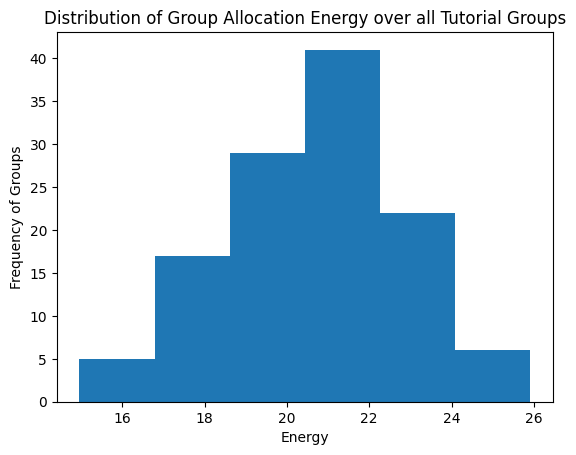

In [25]:
# Distribution of Energies for each Tutorial Group (Histogram)
print(f"Mean and stddev of energy per group: {mean_stddev(energy_distrib)}")

plt.title("Distribution of Group Allocation Energy over all Tutorial Groups")
plt.xlabel("Energy")
plt.ylabel("Frequency of Groups")
plt.hist(energy_distrib, bins=6)
plt.show()

For reference, the graph below is a pre-generated version of what the code generates.

![Distribution of Group Allocation Energy over all Tutorial Groups](assets/energy_distribution_plot.png)

We have found that the mean energy of the groupings over each tutorial group is $20.68$. That is, the average sum of $L_2$ norms of all groups in a tutorial group is around $20.68$. The 95% confidence interval of energy is $[15.79, 25.57]$.

#### **Analyzing the Gender Distribution**

Most males in any tutorial group: 30
Tutorial group(s) with most males: ['G-83', 'G-95']
Least males in any tutorial group: 16
Tutorial group(s) with least males: ['G-4', 'G-97']
Theoretical minimum number of groups with exactly one male: 26
[0, 26, 790, 384, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


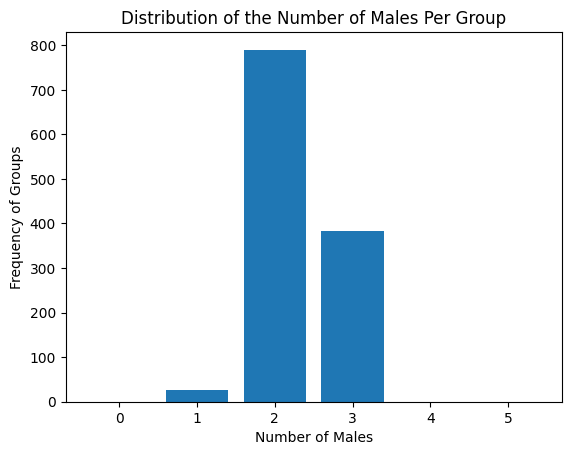

In [26]:
# Distribution of Gender
print(f"Most males in any tutorial group: {max_num_males}")
print(f"Tutorial group(s) with most males: {tut_group_most_male}")

print(f"Least males in any tutorial group: {min_num_males}")
print(f"Tutorial group(s) with least males: {tut_group_least_male}")

print(f"Theoretical minimum number of groups with exactly one male: {min_num_groups_with_one_male}")
print(gender_distrib)

plt.title("Distribution of the Number of Males Per Group")
plt.xlabel("Number of Males")
plt.ylabel("Frequency of Groups")
plt.bar(list(range(max_grp_size + 1)), gender_distrib[:max_grp_size + 1])
plt.show()

For reference, the graph below is a pre-generated version of what the code generates.

![Distribution of the Number of Males Per Group](assets/gender_distribution_plot.png)

The most number of males in any tutorial group was $30$ (attained by tutorial groups G-83 and G-95), while the least number of males was $16$ (attained by tutorial groups G-4 and G-97).

Furthermore, out of the $1200$ groups, $1174$ of them contain 2 or 3 males, and are thus balanced in terms of gender. The remaining $26$ groups contain exactly 1 male. Further analysis of the gender distribution with the pigeonhole principle reveals that it is *mathematically impossible* to do better than $26$ groups with exactly 1 male since some tutorial groups had too few males to ensure balanced groups in terms of gender.

We thus conclude that our algorithm achieves the **optimal gender distribution** for our choice of objective function.

#### **Analyzing the Mean CGPA Distribution**

Maximum Absolute Deviation of any CGPA group mean from the Tut group mean: 0.02540000000000031
Mean, Stddev of CGPA group mean - CGPA tut group mean: (2.4829931972814025e-06, 0.002663656696855719)


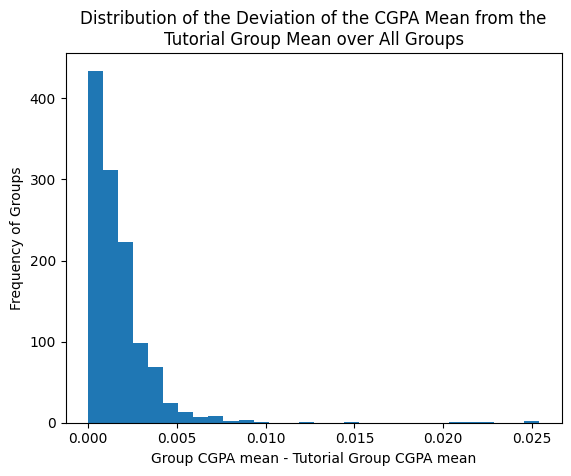

In [27]:
# Plotting the Distribution of Mean Group CGPA (Histogram)
print(f"Maximum Absolute Deviation of any CGPA group mean from the Tut group mean: {max(map(abs, mean_cgpa_distrib))}")

print(f"Mean, Stddev of CGPA group mean - CGPA tut group mean: {mean_stddev(mean_cgpa_distrib)}")

plt.title("Distribution of the Deviation of the CGPA Mean from the\nTutorial Group Mean over All Groups")
plt.xlabel("Group CGPA mean - Tutorial Group CGPA mean")
plt.ylabel("Frequency of Groups")
plt.hist(list(map(abs, mean_cgpa_distrib)), bins=30)
plt.show()

For reference, the graph below is a pre-generated version of what the code generates.

![Distribution of the Deviation of the CGPA Mean from the Tutorial Group Mean over All Groups](assets/cgpa_mean_deviation_plot.png)

We consider the difference between group CGPA mean and the tutorial group CGPA means since all groups are formed within a tutorial group, thus the tutorial group CGPA acts as a "ground truth" for what an equitable group CGPA mean would be.

On average, the mean of the CGPA in each group differs from the mean CGPA of the tutorial group by $2.483 \cdot 10^{-6}$. The largest deviation between the mean CGPA of any group from the mean CGPA of the tutorial group is $0.0254$.

#### **Analyzing School Diversity**

Mean number of distinct schools per group: 4.9775
Max number of distinct schools per group: 5
Min number of distinct schools per group: 4
Percentage of groups with 5 distinct schools: 97.75%
Minimum possible number of groups with four distinct schools: 26


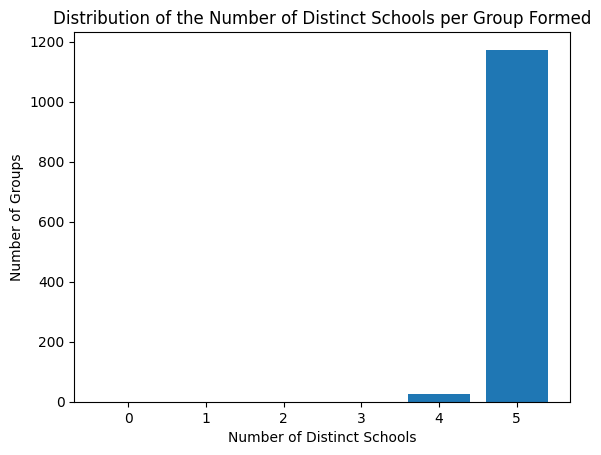

In [28]:
# Printing Stats about the Distribution of the Number of Schools in a Group
print(f"Mean number of distinct schools per group: {sum(num_schools_distrib) / len(num_schools_distrib)}")
print(f"Max number of distinct schools per group: {max(num_schools_distrib)}")
print(f"Min number of distinct schools per group: {min(num_schools_distrib)}")

print(f"Percentage of groups with 5 distinct schools: {len(list(filter(lambda x: x == 5, num_schools_distrib))) / len(num_schools_distrib) * 100}%")

print(f"Minimum possible number of groups with four distinct schools: {min_num_groups_with_four_schools}")

## Plotting the Distribution of the Number of Distinct Schools per Group
plt.title("Distribution of the Number of Distinct Schools per Group Formed")
plt.xlabel("Number of Distinct Schools")
plt.ylabel("Number of Groups")
plt.bar(list(range(max_grp_size + 1)), num_schools_distrib_freq[:max_grp_size + 1])
plt.show()

For reference, the graph below is a pre-generated version of what the code generates.

![Distribution of the Number of Distinct Schools per Group Formed](assets/num_school_distrib_plot.png)

The mean number of distinct schools per group is $4.9775$. $1173$ of the $1200$ groups ($97.75\%$) were composed of students from $5$ different schools. The rest of the $27$ groups ($2.25\%$) were composed of students from $4$ different schools --- i.e., one school was represented twice in these groups.

A similar analysis with the pigeonhole principle reveals that $26$ of these groups are *mathematically guaranteed* to exist in any grouping of students. Thus, our algorithm only produces one extraneous group with $4$ distinct schools, indicating that it achieves **near optimality** in terms of school distribution. 

#### **Analyzing the Algorithm's Effectiveness Over Different Hyperparameter Values** 

[0.01, 0.025, 0.05, 0.075, 0.1, 0.15, 0.2, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0, 7.5, 10.0, 12.5, 15.0, 17.5, 20.0, 30.0, 40.0, 50.0, 75.0, 100.0, 125.0, 150.0, 200.0, 250.0, 300.0, 400.0, 500.0, 750.0, 1000.0]
[10.0, 25.0, 50.0, 125.0, 250.0, 500.0, 1000.0, 2000.0, 4000.0]


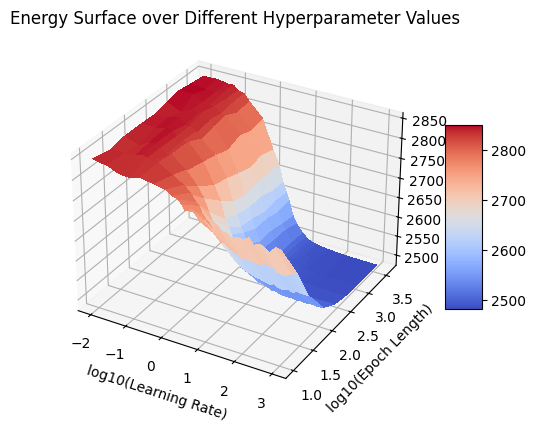

In [29]:
# 2d Plot of the Hyperparameter Search
## Reading the hyperparameters
hyperparam_data_file = in_hyperparam_fname

hyperparam_data = []

with open(hyperparam_data_file) as f:
    hyperparam_data = list(map(lambda x: tuple(map(float, x.strip().split(", "))), f.readlines()))

## Sort the data by learning rate, then by number of epochs
hyperparam_data.sort()

distinct_x = list(set(map(lambda x: x[0], hyperparam_data)))
distinct_y = list(set(map(lambda x: x[1], hyperparam_data)))
distinct_x.sort()
distinct_y.sort()

print(distinct_x)
print(distinct_y)

num_distinct_x = len(distinct_x)
num_distinct_y = len(distinct_y)

hyperparam_energies = list(map(lambda _: [0.0] * num_distinct_y, range(num_distinct_x)))

for i in range(num_distinct_x):
    for j in range(num_distinct_y):
        hyperparam_energies[i][j] = hyperparam_data[i * num_distinct_y + j][-1]

fig, ax = plt.subplots(subplot_kw={"projection": "3d"})

# Plot the energy surface using a log-scale for learning rate and epoch length
distinct_x, distinct_y = meshgrid(list(map(log10, distinct_x)), list(map(log10, distinct_y)))

def plot_3d_graph():
    """
    Note: numpy has only been used when absolutely necessary --- in plotting this 3d graph.
    Notice that the import is scoped to within this suite.
    This is to show that numpy has only been used to convert a list to a numpy array,
    which ax.plot_surface expects.
    When we tried inputting a regular array, ax.plot_surface complained that the array was missing the
    ndim property, something that numpy arrays have.
    Further, we have tried creating a wrapper class to artificially include the ndim parameter,
    but that approach failed since the ax.plot_surface function internally converts between different
    representations of numpy lists, so passing in an object that ax.plot_surface does not recognize
    results in an error.

    We concluded that the use of numpy is unavoidable in this case, unless we write our own 3d
    renderer for plotting, which is out-of-scope for this project.
    """
    import numpy as np
    return ax.plot_surface(distinct_x, distinct_y, np.array(transpose(hyperparam_energies)), cmap=cm.coolwarm,
                    linewidth=0, antialiased=False)

surf = plot_3d_graph()

# Setting a label for the x- and y-axes
ax.xaxis.set_label_text(f"log10(Learning Rate)")
ax.yaxis.set_label_text(f"log10(Epoch Length)")
ax.zaxis.set_label_text(f"Total Energy")
ax.set_title("Energy Surface over Different Hyperparameter Values")

# Customize the z axis.
# ax.set_zlim(-1.01, 1.01)
# ax.zaxis.set_major_locator(LinearLocator(10))
# A StrMethodFormatter is used automatically
# ax.zaxis.set_major_formatter('{x:.02f}')

# Add a color bar which maps values to colors.
fig.colorbar(surf, shrink=0.5, aspect=5)

plt.show()

For reference, the graph below is a pre-generated version of what the code generates.

![Energy Surface over Different Hyperparameter Values](assets/hyperparam_plot.png)

The graph above shows the total energy across all tutorial groups for different choices of the hyperparameter values.

We used a logarithmic scale for the learning rate and the epoch length to better demonstrate the behavior of our algorithm for different values of the learning rate and the epoch length. Note that in our hyperparameter search, we implicitly set `sim_annealing_instances` to `4000/epoch_length`.

As seen in the graph above, the energy is minimized when we *maximize both the epoch length and the learning rate*. Recall that the *higher the learning rate*, the *more greedily* the algorithm behaves. This is why we set the greedy flag to true when running simulated annealing --- The hyperparameter search indicates that, for our problem, being greedy is better.

Notice how the energy surface flattens out to a minimum total energy of $2480.94$. Given our previous data analysis, this value may be quite close to optimal already.

### **Justification of the Use of Heuristic Algorithms**

Sometimes, it may be possible to find an **exact** algorithm to solve the problem.

In our scenario, there is a straightforward brute force that involves generating every possible grouping of students (say, by brute forcing every possible permutation of group codes). This *will* give an exact solution to the problem, but it does not scale well to larger datasets.

In fact, we have found that the resulting discrete optimization problem is **NP-Hard**. That is, it is at least as hard as other problems that Computer Science researchers have found no fast (specifically, *strongly polynomial-time*) algorithms for. The proof is shown in the appendix.

This analysis guided us to using heuristic algorithms to attack the problem. Instead of using exact, but slow and unscaleable algorithms, we opted to use approximate but fast algorithms. The data analysis shows that the resulting heuristic algorithm is both efficient and effective, so we conclude that the use of heuristics is justified in this scenario.

## **Appendices**

### **Proof of Computational Hardness**

We want to show that our optimization problem:

> Compute $\argmin_{T \in \text{Partition}(S_k)} \sum_{t \in T} \left|\left|\frac{1}{|t|} \sum_{\vec{v} \in t} \vec{v}\right|\right|^2 $

is **NP-Hard**.

__Proof:__

We achieve this by **reduction from a known NP-Hard problem**, namely, the **Number Partitioning Problem**.

The **Number Partitioning Problem** is as follows:

> Given a multiset $S$ of real numbers, find the subset $T \in S$ satisfying $\sum_{v \in T} v \le \frac{1}{2} \sum_{v \in S} v $ which maximizes $\sum_{v \in T} v$

This problem is **NP-Complete** and is thus also **NP-Hard** by definition. (Schreiber et al., 2018)

Now, let $S'$ be the multiset containing exactly the same elements as $S$ in the exact same quantities, but with an extra $|S|$ zeroes added.

We note that there exists a subset $T \subseteq S$ satisfying $\sum_{v \in T} v \le \frac{1}{2} \sum_{v \in S} v$ if and only if there exists a subset $T' \subseteq S'$ satisfying both $\sum_{v \in T'} v \le \frac{1}{2} \sum_{v \in S'} v$ and $|T'| = \frac{|S'|}{2} = |S|$.

Let us prove the forward direction. Suppose there exists a subset $T \subseteq S$ satisfying $\sum_{v \in T} v \le \frac{1}{2} \sum_{v \in S} v$, then we can construct the subset $T' \subseteq S'$ satisfying the conditions above by appending $|S| - |T|$ zeroes to $T$.

Let us now prove the backward direction. Suppose there exists a subset $T' \subseteq S'$ satisfying both $\sum_{v \in T'} v \le \frac{1}{2} \sum_{v \in S'} v$ and $|T'| = \frac{|S'|}{2} = |S|$. Then, it must contain at least $\max(0, |T'| - |S|)$ zeros (by the pigeonhole principle). Remove all zeros. You are left with a set $T$ that contains at most $|S|$ elements and that satisfies $T \in S$. Furthermore, since we have only removed zeros, $\sum_{v \in T} v = \sum_{v \in T'} v \le \frac{1}{2} \sum_{v \in S'} v$. We have thus constructed a subset $T \subseteq S$ satisfying $\sum_{v \in T} v \le \frac{1}{2} \sum_{v \in S} v$.

Therefore, finding the subset $T \in S$ satisfying $\sum_{v \in T} v \le \frac{1}{2} \sum_{v \in S} v $ which maximizes $\sum_{v \in T} v$ is equivalent to finding the subset $T' \in S'$ satisfying both $\sum_{v \in T'} v \le \frac{1}{2} \sum_{v \in S'} v$ and $|T'| = \frac{|S'|}{2} = |S|$.

Let $u = \frac{1}{2} \sum_{v \in S'}$. Furthermore, let $S'' = \left\{v - \frac{2 u}{|S'|} \Big\vert v \in S'\right\}$. Notice that there exists a subset $T'' \subseteq S''$ satisfying both $\sum_{v \in T''} v \le 0$ and $|T''| = \frac{|S''|}{2}$ if and only if there exists a subset $T' \subseteq S'$ satisfying both $\sum_{v \in T'} v \le \frac{1}{2} \sum_{v \in S'} v$ and $|T'| = \frac{|S'|}{2} = |S|$.

To show the forward direction, suppose we have a subset $T'' \subseteq S''$ satisfying both $\sum_{v \in T''} v \le 0$ and $|T''| = \frac{|S''|}{2}$. Let $T'$ be the multiset obtained by adding $\frac{2 u}{|S'|}$ to each element of $T''$. Then,

$$
\begin{align*}
\sum_{v \in T'} v & = \sum_{v \in T''} \left(v + \frac{2 u}{|S'|}\right) \\ 
& = \sum_{v \in T''} (v) + \frac{2 u}{|S'|} \sum_{v \in T''} 1 \\ 
& = \sum_{v \in T''} (v) + \frac{2 u}{|S'|} |T''| \\
& = \sum_{v \in T''} (v) + \frac{2 u}{|S'|} \frac{|S''|}{2} \\ 
& = \sum_{v \in T''} (v) + \frac{2 u}{|S'|} \frac{|S'|}{2} \\ 
& = \sum_{v \in T''} (v) + u \\
& \le 0 + u \\ 
& \le u \\ 
& \le \frac{1}{2} \sum_{v \in S'} v \\ 
\end{align*}
$$

We have thus constructed a subset $T' \subseteq S'$ satisfying both $\sum_{v \in T'} v \le \frac{1}{2} \sum_{v \in S'} v$ and $|T'| = \frac{|S'|}{2} = |S|$. This proves the forward direction.

To show the backward direction, suppose we have a subset $T' \subseteq S'$ satisfying both $\sum_{v \in T'} v \le \frac{1}{2} \sum_{v \in S'} v$ and $|T'| = \frac{|S'|}{2} = |S|$. Similarly, we can construct $T''$ by subtracting $\frac{2 u}{|S'|}$ to each element of $T'$. Similar analysis proves the backward direction.

Our original number partitioning problem is thus equivalent to finding the subset $T'' \subseteq S''$ satisfying both $\sum_{v \in T''} v \le 0$ and $|T''| = \frac{|S''|}{2}$ that maximizes $\sum_{v \in T''} v$. As a consequence, we also find the subset $R \subseteq S''$ satisfying both $\sum_{v \in R} v \ge 0$ and $|R| = \frac{|S''|}{2}$ that minimizes $\sum_{v \in R} v$ --- simply set $R = S'' - T''$.

This problem is thus equivalent to finding a partition $T'' \cup R = S$ satisfying $|T''| = |R|$ that minimizes $(\sum_{v \in T''} v)^2 + (\sum_{v \in R} v)^2$. Multiplying the objective function by the scalar $\frac{1}{|T''|^2} = \frac{1}{|R|^2}$, we find that this is equivalent to minimizing $(\frac{1}{|T''|} \sum_{v \in T''} v)^2 + (\frac{1}{|R|} \sum_{v \in R} v)^2 = \left|\left|\frac{1}{|T''|} \sum_{v \in T''} v\right|\right|^2 + \left|\left|\frac{1}{|R|} \sum_{v \in R} v\right|\right|^2$.

Thus, we have reduced the original Number Partitioning Problem to an instance of our optimization problem. This implies that our optimization problem is at least as hard as the Number Partitioning Problem, proving that it is, indeed, **NP-Hard**. $\blacksquare$

This suggests that the best we can do is to look for heuristic algorithms to solve the problem, as no polynomial time algorithms may exist unless **P=NP** holds.

## **References**

Schreiber, E. L., Korf, R. E., & Moffitt, M. D. (2018). Optimal multi-way number partitioning. *Journal of the ACM, 65*(4), 1–61. https://doi.org/10.1145/3184400

## Appendix B: Use of AI Tool(s)

Each team member should indicate either A or B:

A. I affirm that my contribution(s) to the lab work is my own, produced without help
from any AI tool(s)

B. I affirm that my contribution(s) to the lab work has been produced with the help
from AI tool(s)

|Full Name|Date|A or B|
|-|-|-|
| Cleavon Yeo Kaiyi | 11-11-2025 | A |
| Darren Ang Hao En | 11-11-2025 | A |
| Denzell Teo Kai Feng | 11-11-2025 | A |
| De Vera Hans Gabriel Dacon | 11-11-2025 | A |
| Dickson Tan Choon Yin | 11-11-2025 | A |

By including this information in your jupyter notebook, you declare that the above
affirmation made is true and that you have read and understood NTU’s policy on the use
of AI tools.